# Preliminary Analysis on Base Questions 1.1

This 1.2 Version of preliminary analysis is based on updated cleaned ridership datasets, 'cleaned_2019-01-03_data' and 'cleaned_2022-01_data' with focus on Januray data of 2019 and 2022. 

This version improved upon some existing issues and concerns from first version.

    1. Solving issues about the definition of 'delayed' by adding a buffer time of one minute.
    
    2. Adding anlysis for early arrivals.
    
    3. Strightforward charts are available for key Stats!
    
Please note that the missing of certain routes(which causes the Q4 and Q5 to have identical chart) has been noticed. We will discussed this issue with the team member who is cleaning this datasets.

More of the clients' concern will be addressed in next version.

#  Package Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# File Loading

Make sure to replace this path with you local path where is stores 'cleaned_2019-01-03_data' and 'cleaned_2022-01_data'.

In [2]:
# Load datasets
df_2019 = pd.read_csv('C:\\Users\\Huihao Xing\\Documents\\临时文件\\G1\\DS 701\\Project\\Dataset\\cleaned_2019-01-03_data.csv', 
                      parse_dates = ['service_date'])
df_2022 = pd.read_csv('C:\\Users\\Huihao Xing\\Documents\\临时文件\\G1\\DS 701\\Project\\Dataset\\cleaned_2022-01_data.csv',
                     parse_dates = ['service_date'])

In [3]:
print(df_2019.dtypes)

service_date                 datetime64[ns]
route_id                              int64
direction                            object
half_trip_id                          int64
stop_id                               int64
time_point_id                        object
time_point_order                      int64
point_type                           object
standard_type                        object
scheduled                            object
actual                               object
scheduled_headway                   float64
headway                             float64
scheduled_datetime                   object
actual_datetime                      object
available_bus_depart_time            object
dtype: object


In [4]:
# Add a column indicating the data source year for differentiation
df_2019['year'] = 2019
df_2022['year'] = 2022

# Combine datasets
df = pd.concat([df_2019, df_2022], ignore_index=True)

In [5]:
# Set a new col for month
df['month'] = df['service_date'].dt.month

# Set month = January
df = df[df['month'] == 1]

# Set year = X
# df = df[df['year'] == X]

df['scheduled'] = pd.to_datetime(df['scheduled'], format='%H:%M:%S', errors='coerce')
df['actual'] = pd.to_datetime(df['actual'], format='%H:%M:%S', errors='coerce')

In [6]:
# Calculate delay in seconds and on-time status with a 1-minute buffer
df['delay_seconds'] = (df['actual'] - df['scheduled']).dt.total_seconds()
df['on_time'] = df['delay_seconds'].abs() <= 60

# Question 3

On average, how long does an individual have to wait for a bus (on time vs. delayed)? 


In [7]:
# Group by route, year, month, and on-time status, then calculate the average wait time
monthly_route_waiting = df.groupby(['route_id', 'year', 'month', 'on_time']).agg(
    avg_wait_time=('delay_seconds', 'mean')
).reset_index()

# Print the results
# print("Monthly average wait times by route and on-time status (on time vs. delayed):")
# print(monthly_route_waiting)

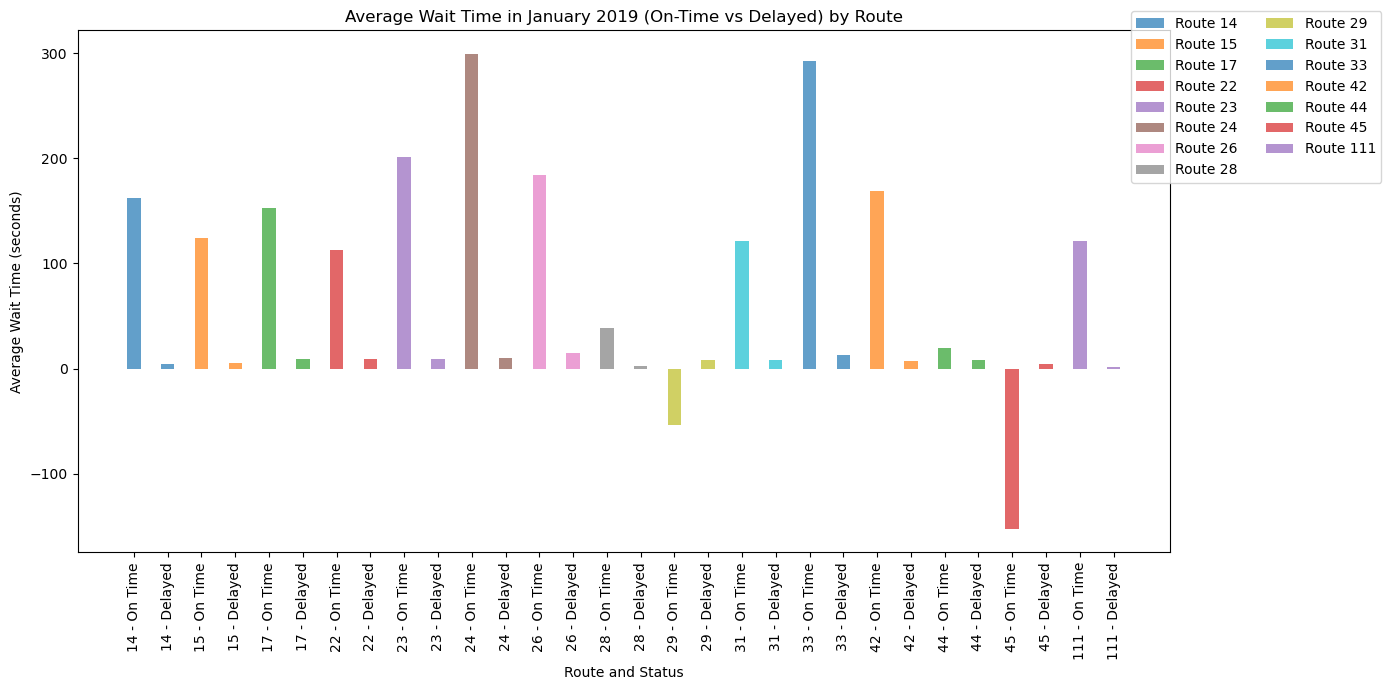

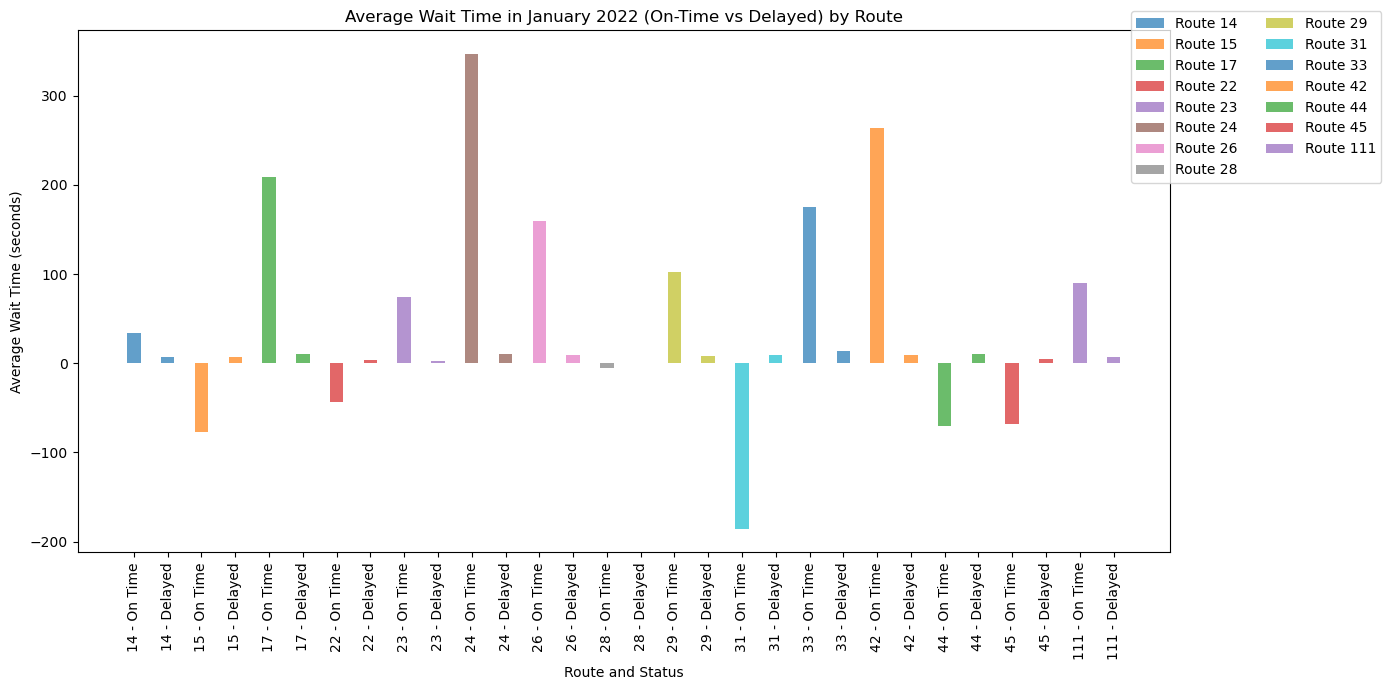

In [8]:
# Group by year, route, and on-time status, then calculate average wait time
avg_wait_time = df.groupby(['year', 'route_id', 'on_time']).agg(
    avg_wait_time=('delay_seconds', 'mean')
).reset_index()

# Plot average wait time for 2019
plt.figure(figsize=(14, 7))
subset_2019 = avg_wait_time[avg_wait_time['year'] == 2019]
for i, route in enumerate(subset_2019['route_id'].unique()):
    route_data = subset_2019[subset_2019['route_id'] == route]
    plt.bar([f"{route} - {status}" for status in ['On Time', 'Delayed']], 
            route_data['avg_wait_time'], width=0.4, alpha=0.7, label=f'Route {route}')
plt.xlabel('Route and Status')
plt.ylabel('Average Wait Time (seconds)')
plt.title('Average Wait Time in January 2019 (On-Time vs Delayed) by Route')
plt.xticks(rotation=90)
plt.legend(loc='upper right', bbox_to_anchor=(1.2, 1.05), ncol=2)
plt.tight_layout()
plt.show()

# Plot average wait time for 2022
plt.figure(figsize=(14, 7))
subset_2022 = avg_wait_time[avg_wait_time['year'] == 2022]
for i, route in enumerate(subset_2022['route_id'].unique()):
    route_data = subset_2022[subset_2022['route_id'] == route]
    plt.bar([f"{route} - {status}" for status in ['On Time', 'Delayed']], 
            route_data['avg_wait_time'], width=0.4, alpha=0.7, label=f'Route {route}')
plt.xlabel('Route and Status')
plt.ylabel('Average Wait Time (seconds)')
plt.title('Average Wait Time in January 2022 (On-Time vs Delayed) by Route')
plt.xticks(rotation=90)
plt.legend(loc='upper right', bbox_to_anchor=(1.2, 1.05), ncol=2)
plt.tight_layout()
plt.show()


# Extra Question from Client 

Having a bus arrive early is “more harmful” than a bus that arrives a bit late. Because, generally speaking, a person will be more likely to miss the bus completely if it arrives early compared to waiting 2 extra minutes for a late bus but getting onto the same route.

Following cells aim to detect those early arrivals.

In [9]:
# Identify early arrivals (more than 1 minute early)
df['early_arrival'] = df['delay_seconds'] < -60

# Count early arrivals by route, year, and month
monthly_early_arrivals = df[df['early_arrival']].groupby(['route_id', 'year', 'month']).size().reset_index(name='early_arrival_count')

# Count early arrivals by year and route
early_arrival_count = df[df['early_arrival']].groupby(['year', 'route_id']).size().reset_index(name='early_arrival_count')

# Print the results
# print("Monthly count of early arrivals by route:")
# print(monthly_early_arrivals)

In [10]:
# Define a color palette for the routes
colors = [
    '#FF5733', '#33FF57', '#3357FF', '#F1C40F', '#9B59B6',
    '#1ABC9C', '#E67E22', '#34495E', '#7F8C8D', '#FF1493',
    '#FF6F61', '#6C5B7F', '#F67280', '#C06C84', '#6A0572',
    '#AB83B4', '#F6B93B', '#4ECDC4', '#F45D01', '#D94F3A',
    '#C9E4CA', '#4B86B4', '#6F8FAF', '#D9BF77', '#FFB6B9'
]

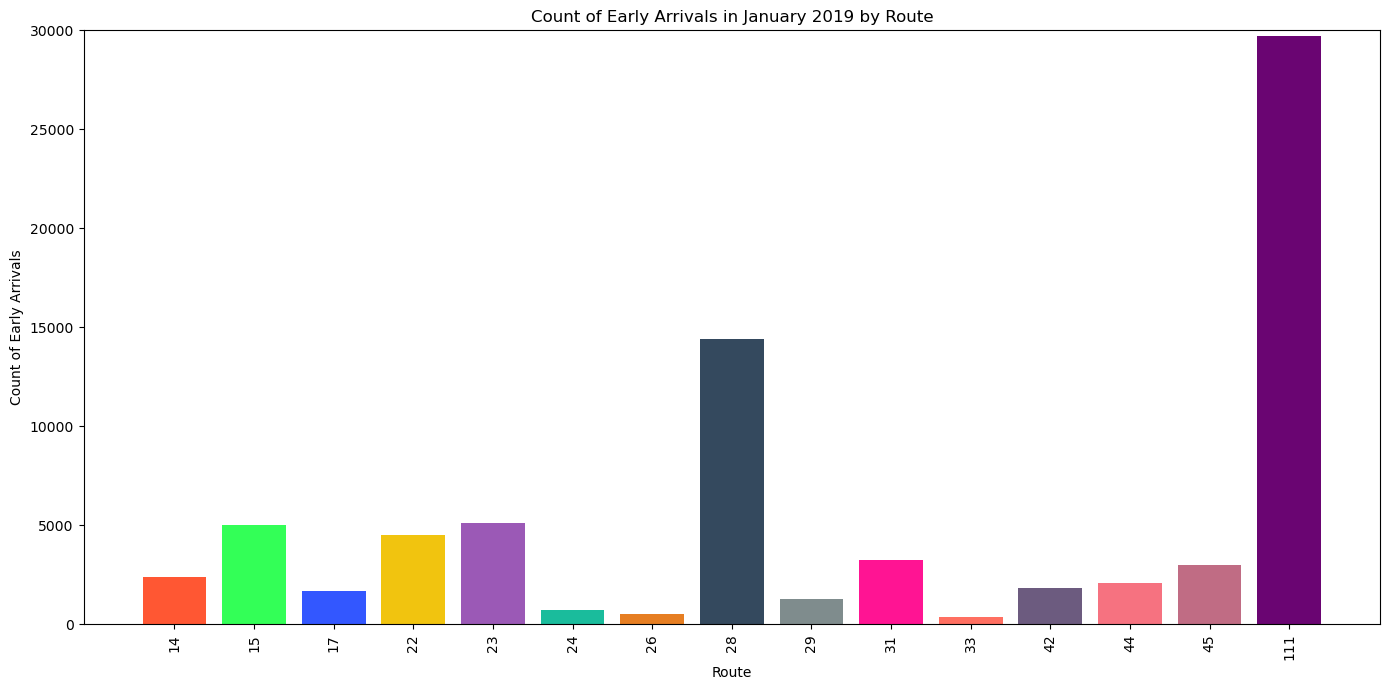

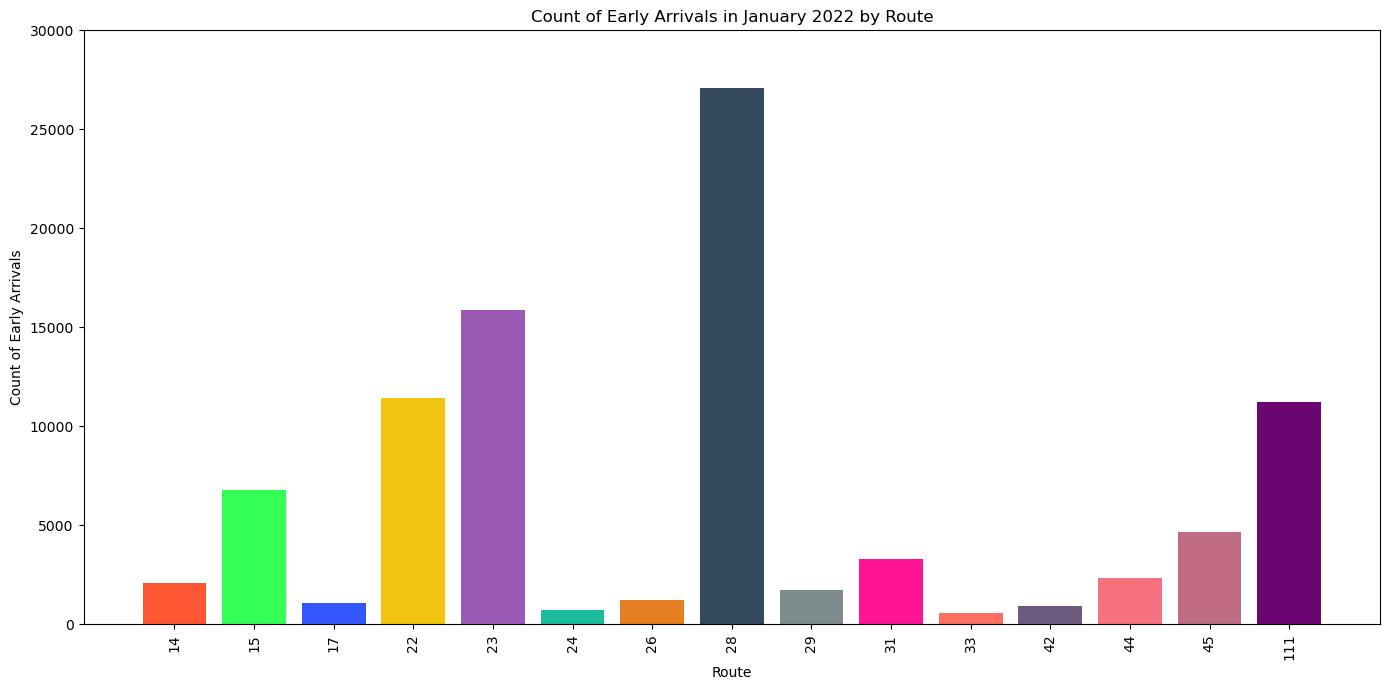

In [11]:
# Find the maximum count of early arrivals across both years
max_early_arrival_count = early_arrival_count['early_arrival_count'].max()

# Plot early arrivals for 2019
plt.figure(figsize=(14, 7))
subset_2019 = early_arrival_count[early_arrival_count['year'] == 2019]
plt.bar(subset_2019['route_id'].astype(str), 
        subset_2019['early_arrival_count'], 
        color=colors[:len(subset_2019)])
plt.ylim(0, 30000) 
plt.xlabel('Route')
plt.ylabel('Count of Early Arrivals')
plt.title('Count of Early Arrivals in January 2019 by Route')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# Repeat for 2022 using the same Y-axis limit


# Plot early arrivals categorized by routes for 2022
plt.figure(figsize=(14, 7))
subset_2022 = early_arrival_count[early_arrival_count['year'] == 2022]
plt.bar(subset_2022['route_id'].astype(str), 
        subset_2022['early_arrival_count'], 
        color=colors[:len(subset_2022)])  # Adjust colors based on number of routes
plt.xlabel('Route')
plt.ylabel('Count of Early Arrivals')
plt.title('Count of Early Arrivals in January 2022 by Route')
plt.xticks(rotation=90)
plt.ylim(0, 30000) 
plt.tight_layout()
plt.show()

# Extending - Percentage

In [12]:
# Count total arrivals by year and route
total_arrival_count = df.groupby(['year', 'route_id']).size().reset_index(name='total_arrival_count')

# Merge early arrival counts with total arrivals for 2019
early_arrival_percentage_2019 = early_arrival_count[early_arrival_count['year'] == 2019].merge(total_arrival_count[total_arrival_count['year'] == 2019], on='route_id')
early_arrival_percentage_2019['early_arrival_percentage'] = (early_arrival_percentage_2019['early_arrival_count'] / early_arrival_percentage_2019['total_arrival_count']) * 100

# Merge early arrival counts with total arrivals for 2022
early_arrival_percentage_2022 = early_arrival_count[early_arrival_count['year'] == 2022].merge(total_arrival_count[total_arrival_count['year'] == 2022], on='route_id')
early_arrival_percentage_2022['early_arrival_percentage'] = (early_arrival_percentage_2022['early_arrival_count'] / early_arrival_percentage_2022['total_arrival_count']) * 100

# Print early arrival percentages for 2019
# print("Early Arrival Percentages for 2019:")
# print(early_arrival_percentage_2019[['route_id', 'early_arrival_count', 'total_arrival_count', 'early_arrival_percentage']])

# Print early arrival percentages for 2022
# print("\nEarly Arrival Percentages for 2022:")
# print(early_arrival_percentage_2022[['route_id', 'early_arrival_count', 'total_arrival_count', 'early_arrival_percentage']])



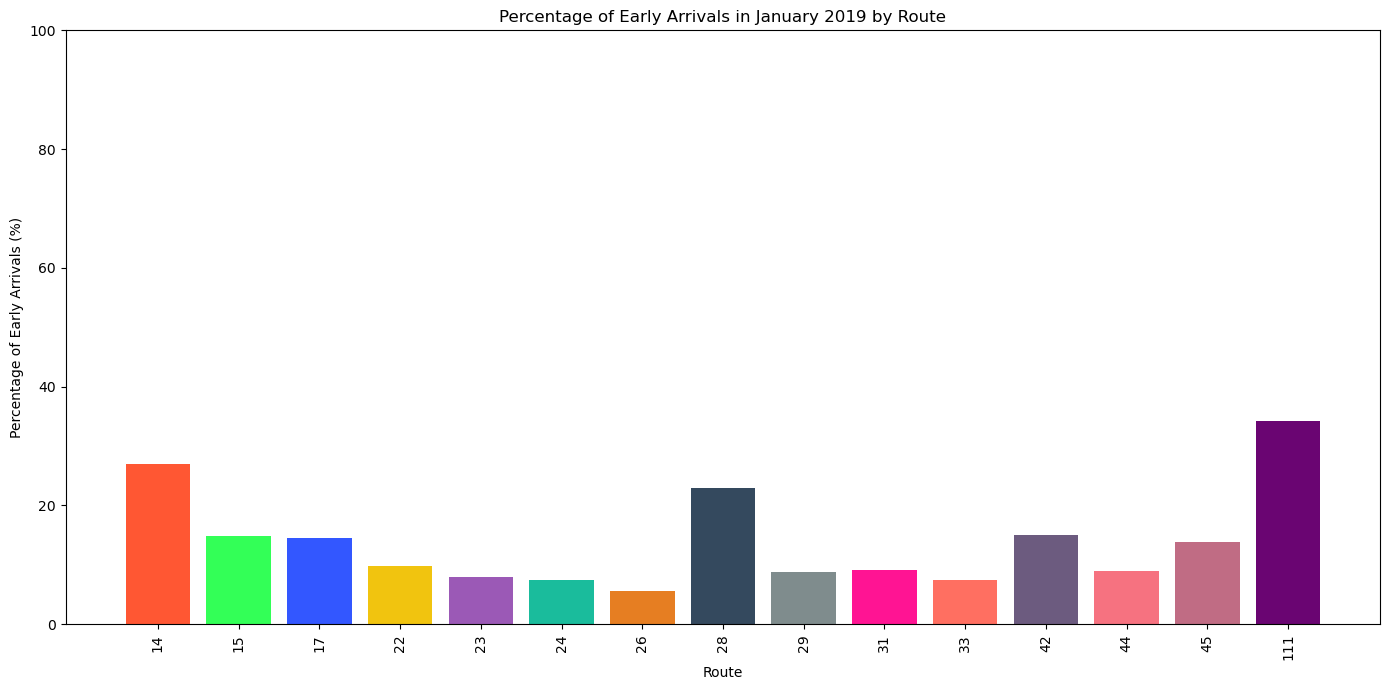

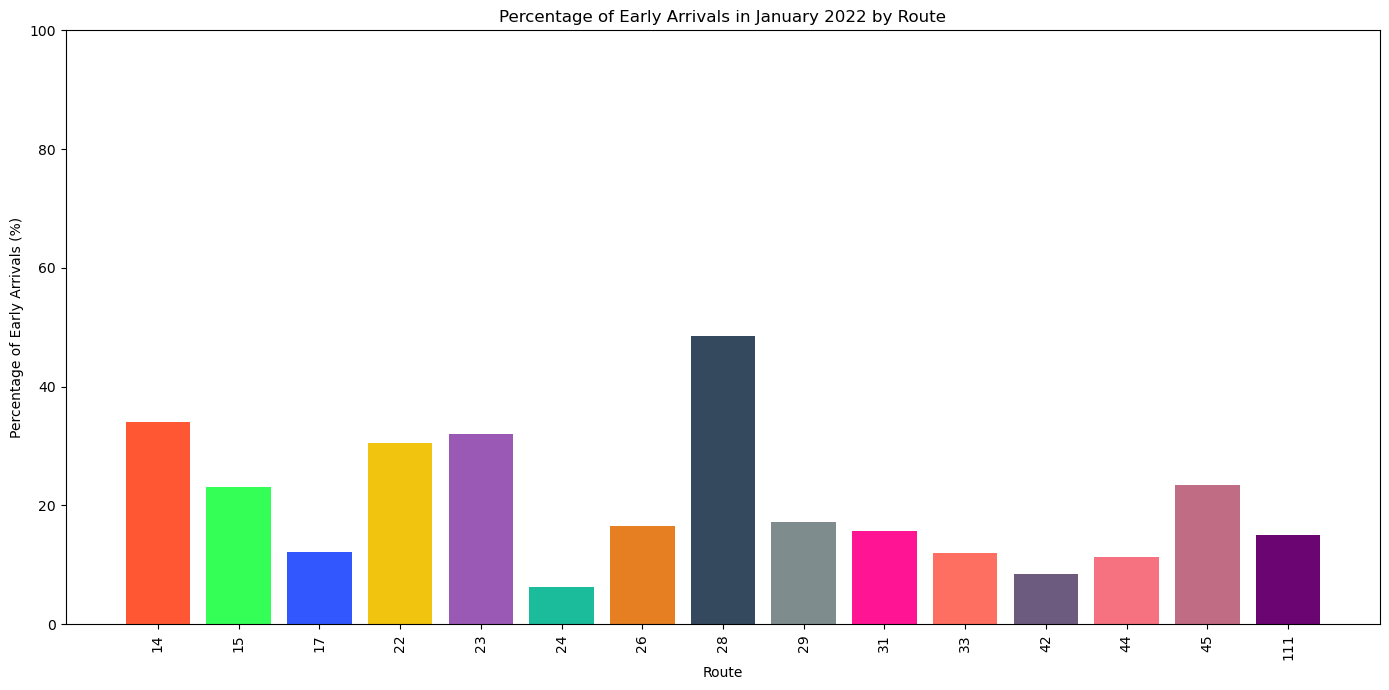

In [13]:
# Find the maximum percentage of early arrivals across both years
max_early_arrival_percentage = max(early_arrival_percentage_2019['early_arrival_percentage'].max(), 
                                   early_arrival_percentage_2022['early_arrival_percentage'].max())

# Plot early arrival percentages for 2019
plt.figure(figsize=(14, 7))
plt.bar(early_arrival_percentage_2019['route_id'].astype(str), 
        early_arrival_percentage_2019['early_arrival_percentage'], 
        color=colors[:len(early_arrival_percentage_2019)])  # Adjust colors based on number of routes
plt.xlabel('Route')
plt.ylabel('Percentage of Early Arrivals (%)')
plt.title('Percentage of Early Arrivals in January 2019 by Route')
plt.xticks(rotation=90)
plt.ylim(0, 100) 
plt.tight_layout()
plt.show()

# Plot early arrival percentages for 2022
plt.figure(figsize=(14, 7))
plt.bar(early_arrival_percentage_2022['route_id'].astype(str), 
        early_arrival_percentage_2022['early_arrival_percentage'], 
        color=colors[:len(early_arrival_percentage_2022)])  # Adjust colors based on number of routes
plt.xlabel('Route')
plt.ylabel('Percentage of Early Arrivals (%)')
plt.title('Percentage of Early Arrivals in January 2022 by Route')
plt.xticks(rotation=90)
plt.ylim(0, 100) 
plt.tight_layout()
plt.show()


# Extending

What is the average time for those early arrival?


In [14]:
# Calculate the average early arrival time by route, year, and month
monthly_avg_early_arrival = df[df['early_arrival']].groupby(['route_id', 'year', 'month']).agg(
    avg_early_arrival_time=('delay_seconds', 'mean')
).reset_index()

# Convert early arrival times from seconds to minutes for readability
monthly_avg_early_arrival['avg_early_arrival_time_minutes'] = monthly_avg_early_arrival['avg_early_arrival_time'] / 60


# Calculate average early arrival time by year and route
avg_early_arrival_time = df[df['early_arrival']].groupby(['year', 'route_id']).agg(
    avg_early_arrival_time=('delay_seconds', 'mean')
).reset_index()

# Convert early arrival time from seconds to minutes for readability
avg_early_arrival_time['avg_early_arrival_time_minutes'] = avg_early_arrival_time['avg_early_arrival_time'] / 60


# Print the results
# print("Monthly average early arrival time (in minutes) by route:")
# print(monthly_avg_early_arrival)



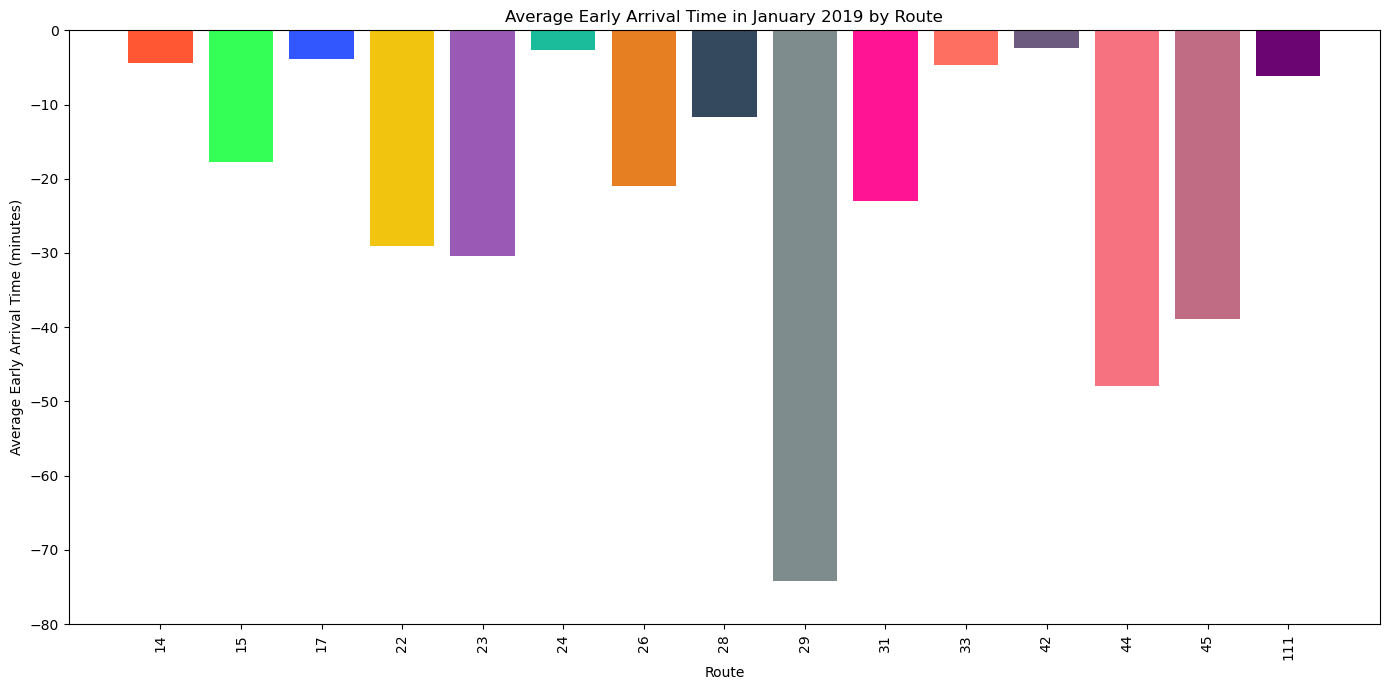

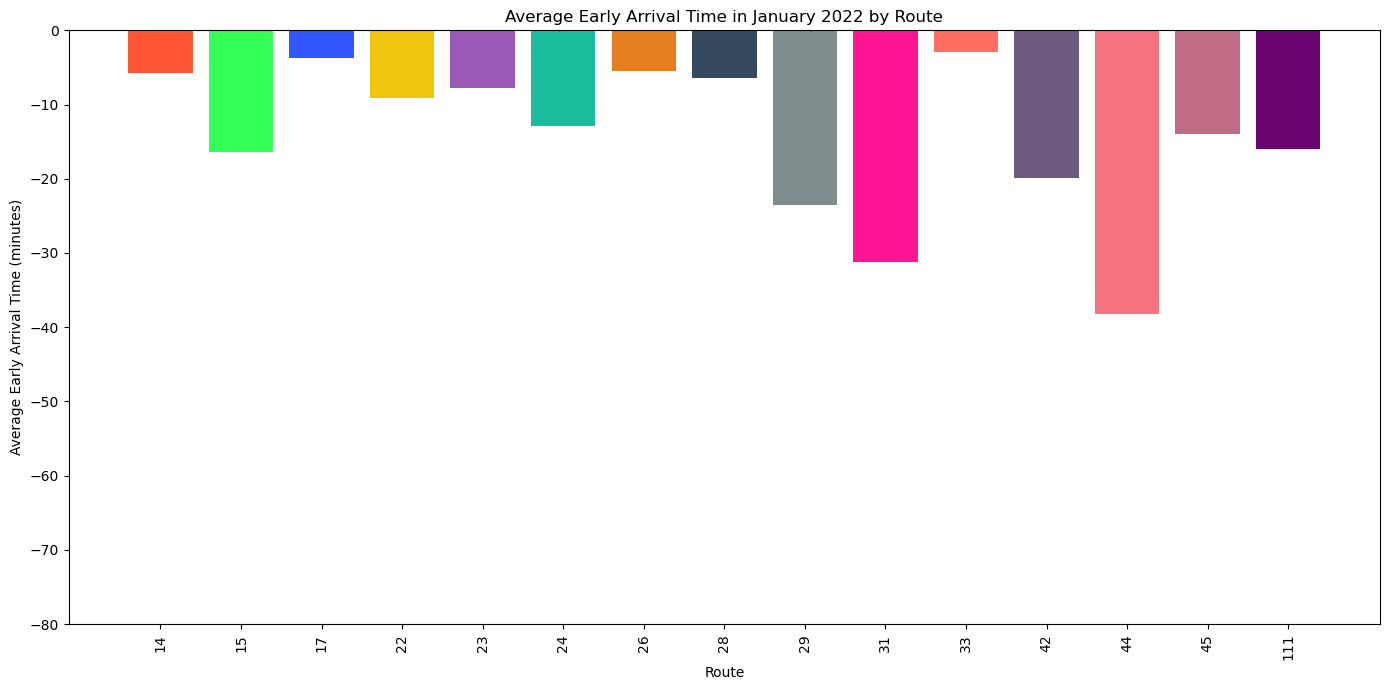

In [15]:
# Find the maximum average early arrival time across both years
max_avg_early_arrival_time = max(avg_early_arrival_time['avg_early_arrival_time_minutes'].max(), 
                                 avg_early_arrival_time['avg_early_arrival_time_minutes'].max())

# Plot average early arrival time for 2019
plt.figure(figsize=(14, 7))
subset_2019 = avg_early_arrival_time[avg_early_arrival_time['year'] == 2019]
plt.bar(subset_2019['route_id'].astype(str), 
        subset_2019['avg_early_arrival_time_minutes'], 
        color=colors[:len(subset_2019)])  # Adjust colors based on number of routes
plt.xlabel('Route')
plt.ylabel('Average Early Arrival Time (minutes)')
plt.title('Average Early Arrival Time in January 2019 by Route')
plt.xticks(rotation=90)
plt.ylim(-80, 0)  # Set y-axis limit
plt.tight_layout()
plt.show()

# Plot average early arrival time for 2022
plt.figure(figsize=(14, 7))
subset_2022 = avg_early_arrival_time[avg_early_arrival_time['year'] == 2022]
plt.bar(subset_2022['route_id'].astype(str), 
        subset_2022['avg_early_arrival_time_minutes'], 
        color=colors[:len(subset_2022)])  # Adjust colors based on number of routes
plt.xlabel('Route')
plt.ylabel('Average Early Arrival Time (minutes)')
plt.title('Average Early Arrival Time in January 2022 by Route')
plt.xticks(rotation=90)
plt.ylim(-80,0)  # Set y-axis limit
plt.tight_layout()
plt.show()


# Question 4

What is the average delay time of all routes across the entire city?

In [16]:
# Filter to delayed entries and calculate the average delay per month
monthly_avg_delay_citywide = df[~df['on_time']].groupby(['year', 'month']).agg(
    avg_citywide_delay=('delay_seconds', 'mean')
).reset_index()

# Convert delay time from seconds to minutes
monthly_avg_delay_citywide['avg_citywide_delay_minutes'] = monthly_avg_delay_citywide['avg_citywide_delay'] / 60


# Filter to delayed entries and calculate average delay by year and route
citywide_avg_delay = df[~df['on_time']].groupby(['year', 'route_id']).agg(
    avg_citywide_delay=('delay_seconds', 'mean')
).reset_index()

# Convert delay time from seconds to minutes
citywide_avg_delay['avg_citywide_delay_minutes'] = citywide_avg_delay['avg_citywide_delay'] / 60

# Print the results
# print("Monthly average delay across all routes (city-wide):")
# print(monthly_avg_delay_citywide)


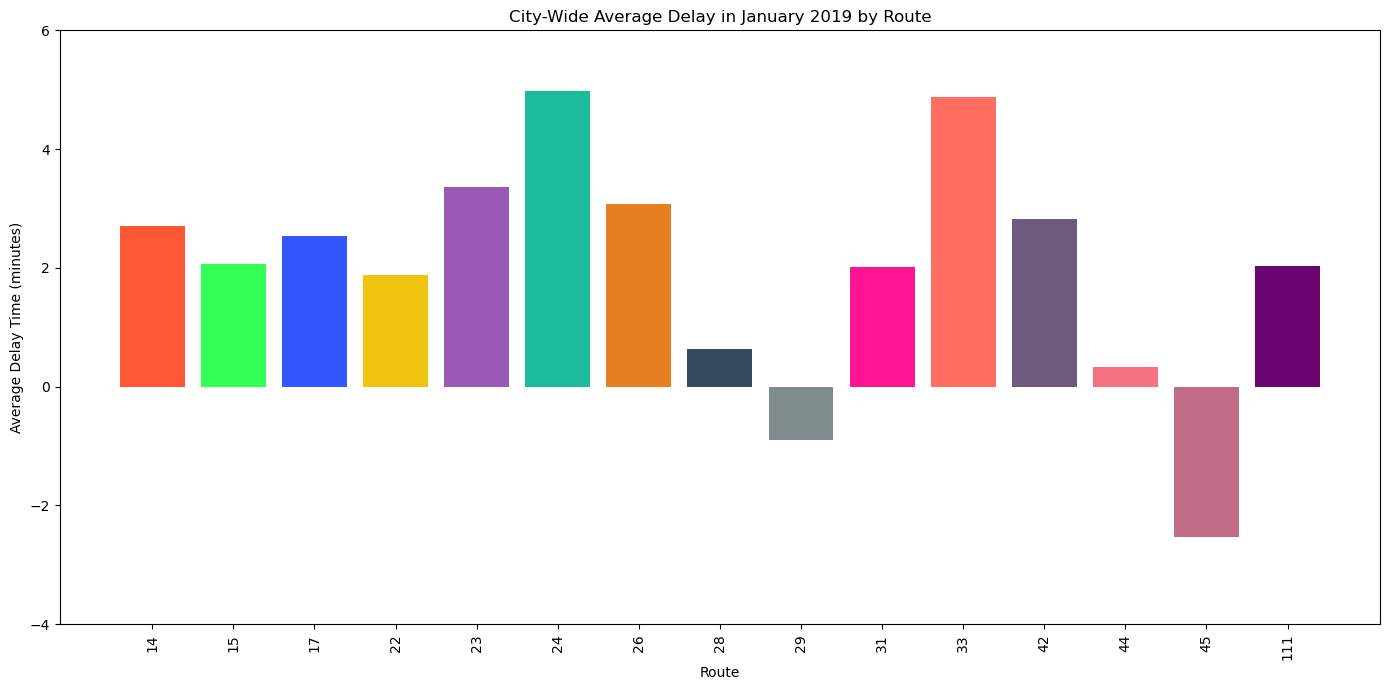

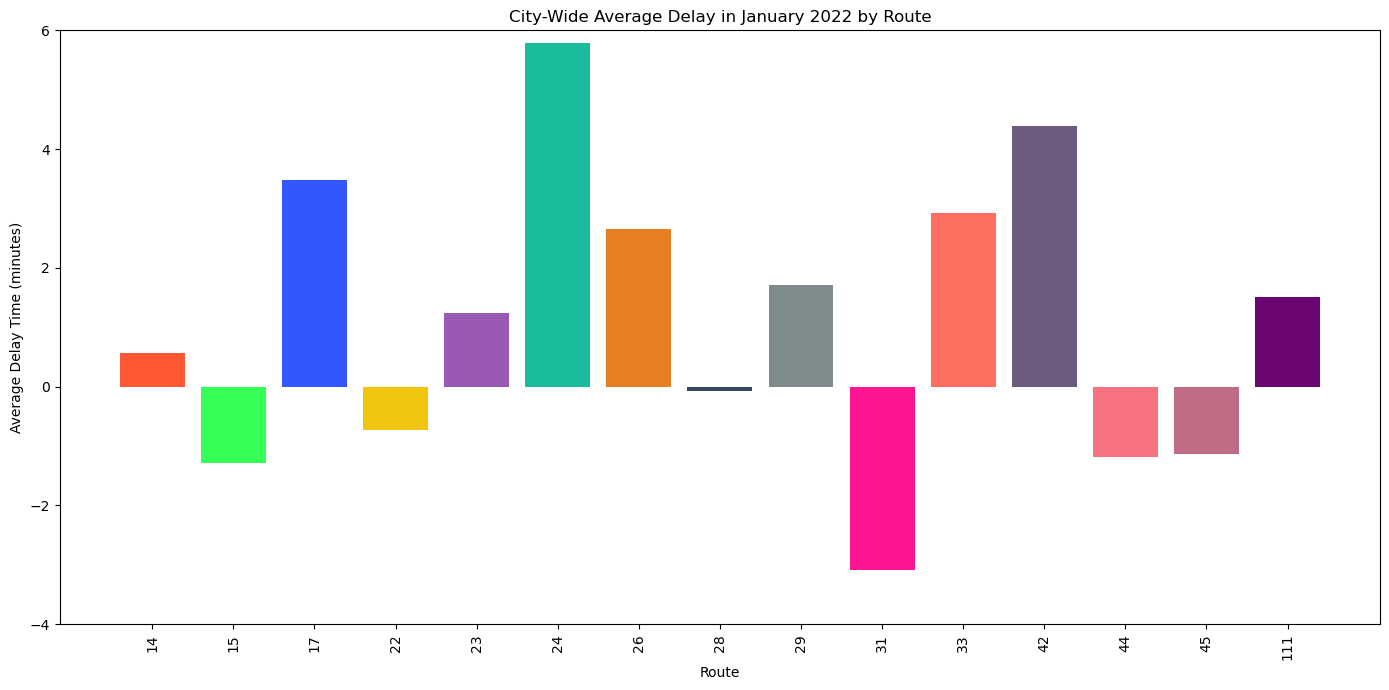

In [17]:
plt.figure(figsize=(14, 7))
subset_2019 = citywide_avg_delay[citywide_avg_delay['year'] == 2019]
plt.bar(subset_2019['route_id'].astype(str), 
        subset_2019['avg_citywide_delay_minutes'], 
        color=colors[:len(subset_2019)])  # Adjust colors based on number of routes
plt.xlabel('Route')
plt.ylabel('Average Delay Time (minutes)')
plt.title('City-Wide Average Delay in January 2019 by Route')
plt.xticks(rotation=90)
plt.ylim(-4,6)
plt.tight_layout()
plt.show()

# Plot city-wide average delay categorized by routes for 2022
plt.figure(figsize=(14, 7))
subset_2022 = citywide_avg_delay[citywide_avg_delay['year'] == 2022]
plt.bar(subset_2022['route_id'].astype(str), 
        subset_2022['avg_citywide_delay_minutes'], 
        color=colors[:len(subset_2022)])  # Adjust colors based on number of routes
plt.xlabel('Route')
plt.ylabel('Average Delay Time (minutes)')
plt.title('City-Wide Average Delay in January 2022 by Route')
plt.xticks(rotation=90)
plt.ylim(-4,6)
plt.tight_layout()
plt.show()

# Question 5

What is the average delay time of the target bus routes (22, 29, 15, 45, 28, 44, 42, 17, 23, 31, 26, 111, 24, 33, 14 - from Livable Streets report)?

In [18]:
# Define target routes
target_routes = [22, 29, 15, 45, 28, 44, 42, 17, 23, 31, 26, 111, 24, 33, 14]

# Filter data for target routes and calculate average delay for delayed trips
monthly_target_route_delay = df[(df['route_id'].isin(target_routes)) & (~df['on_time'])].groupby(
    ['route_id', 'year', 'month']
).agg(
    avg_delay_target=('delay_seconds', 'mean')
).reset_index()

# Convert delay time from seconds to minutes
monthly_target_route_delay['avg_delay_target_minutes'] = monthly_target_route_delay['avg_delay_target'] / 60

# Print the results
# print("Monthly average delay for target routes:")
# print(monthly_target_route_delay)



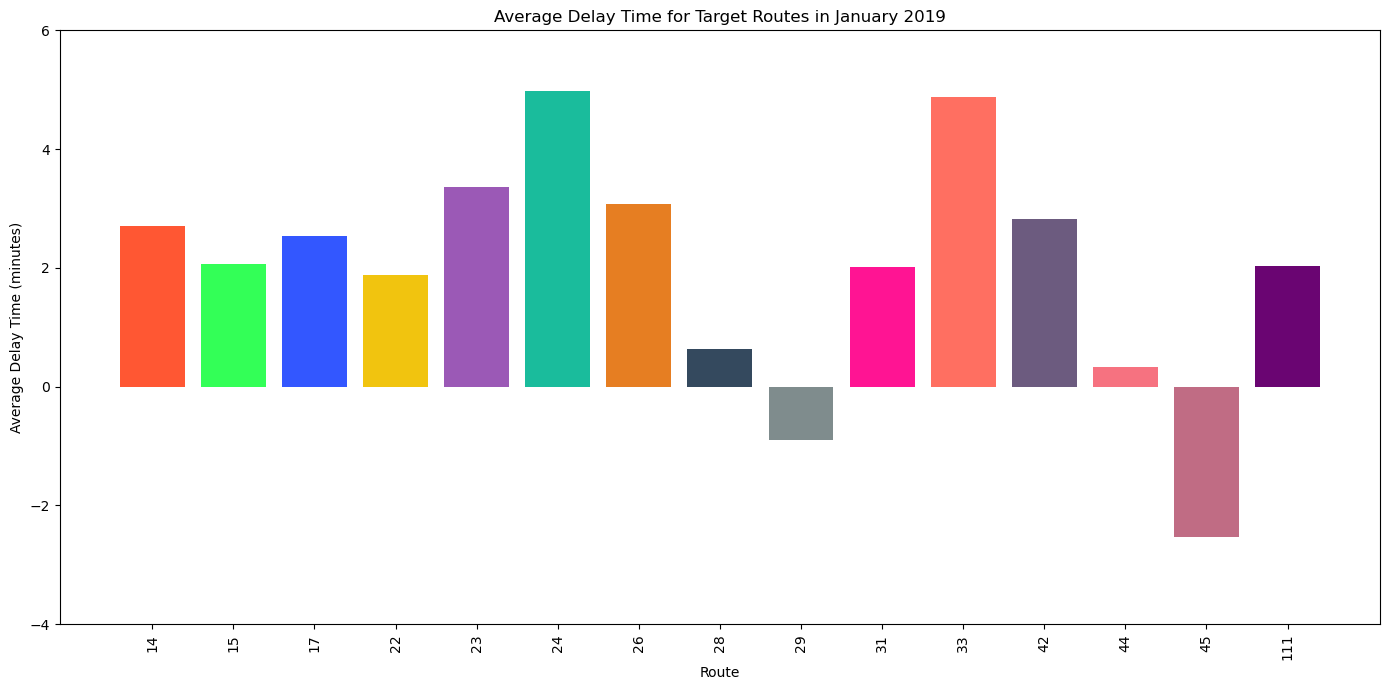

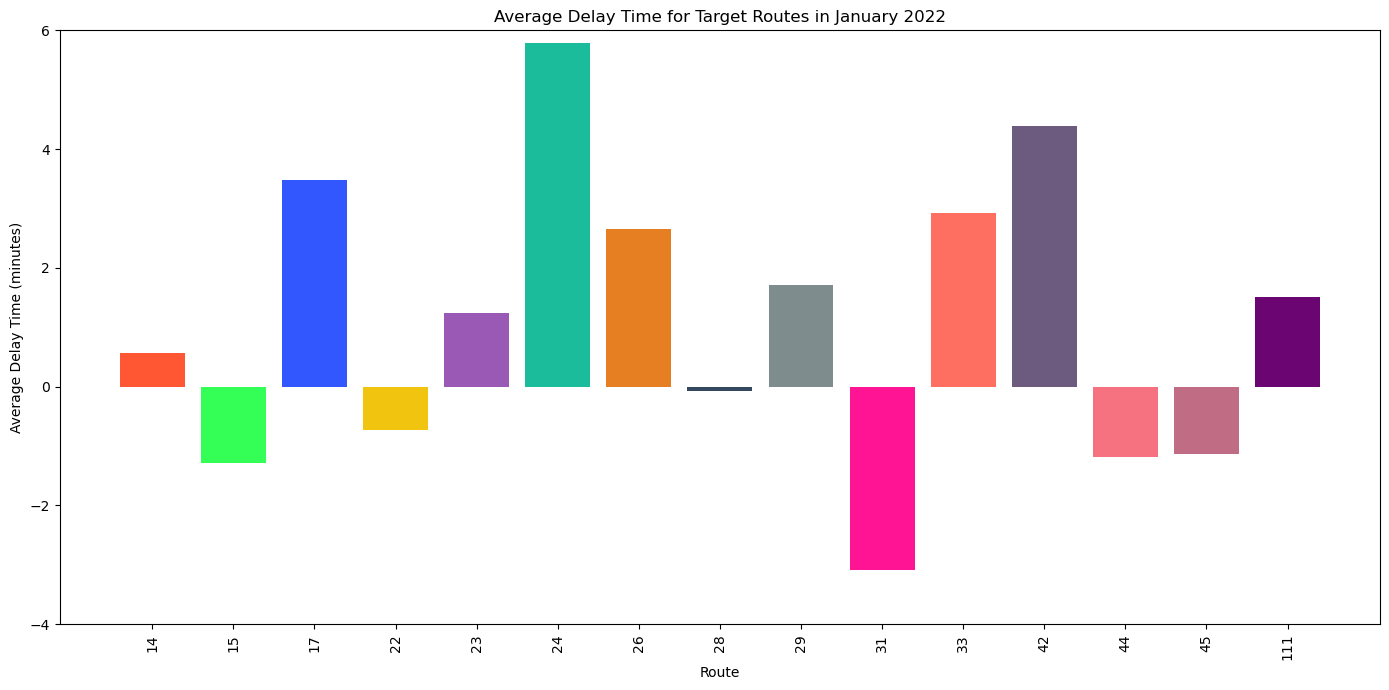

In [19]:
# Plot average delay for target routes in 2019
plt.figure(figsize=(14, 7))
subset_2019 = monthly_target_route_delay[monthly_target_route_delay['year'] == 2019]
plt.bar(subset_2019['route_id'].astype(str), 
        subset_2019['avg_delay_target_minutes'], 
        color=colors[:len(subset_2019)])  # Adjust colors based on number of routes
plt.xlabel('Route')
plt.ylabel('Average Delay Time (minutes)')
plt.title('Average Delay Time for Target Routes in January 2019')
plt.xticks(rotation=90)
plt.ylim(-4,6)
plt.tight_layout()
plt.show()

# Plot average delay for target routes in 2022
plt.figure(figsize=(14, 7))
subset_2022 = monthly_target_route_delay[monthly_target_route_delay['year'] == 2022]
plt.bar(subset_2022['route_id'].astype(str), 
        subset_2022['avg_delay_target_minutes'], 
        color=colors[:len(subset_2022)])  # Adjust colors based on number of routes
plt.xlabel('Route')
plt.ylabel('Average Delay Time (minutes)')
plt.title('Average Delay Time for Target Routes in January 2022')
plt.xticks(rotation=90)
plt.ylim(-4,6)
plt.tight_layout()
plt.show()

# Question 6 

Are there disparities in the service levels of different routes (which lines are late more often than others)?


In [20]:
# Count the number of delayed buses for each route
delayed_buses_count = df[~df['on_time']].groupby(['route_id']).size().reset_index(name='delayed_count')

# Sort the results by delayed count in descending order
delayed_buses_count = delayed_buses_count.sort_values(by='delayed_count', ascending=False)

# Print the results
# print("Count of Delayed Buses by Route:")
# print(delayed_buses_count)

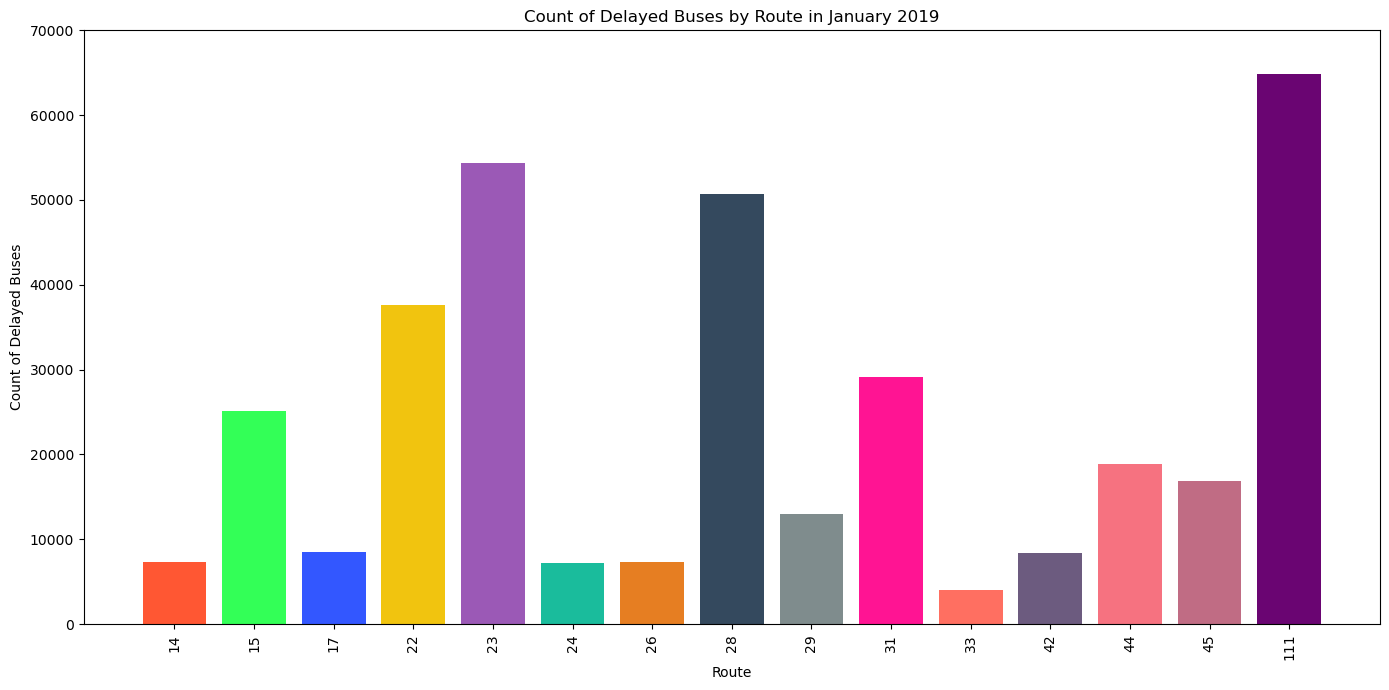

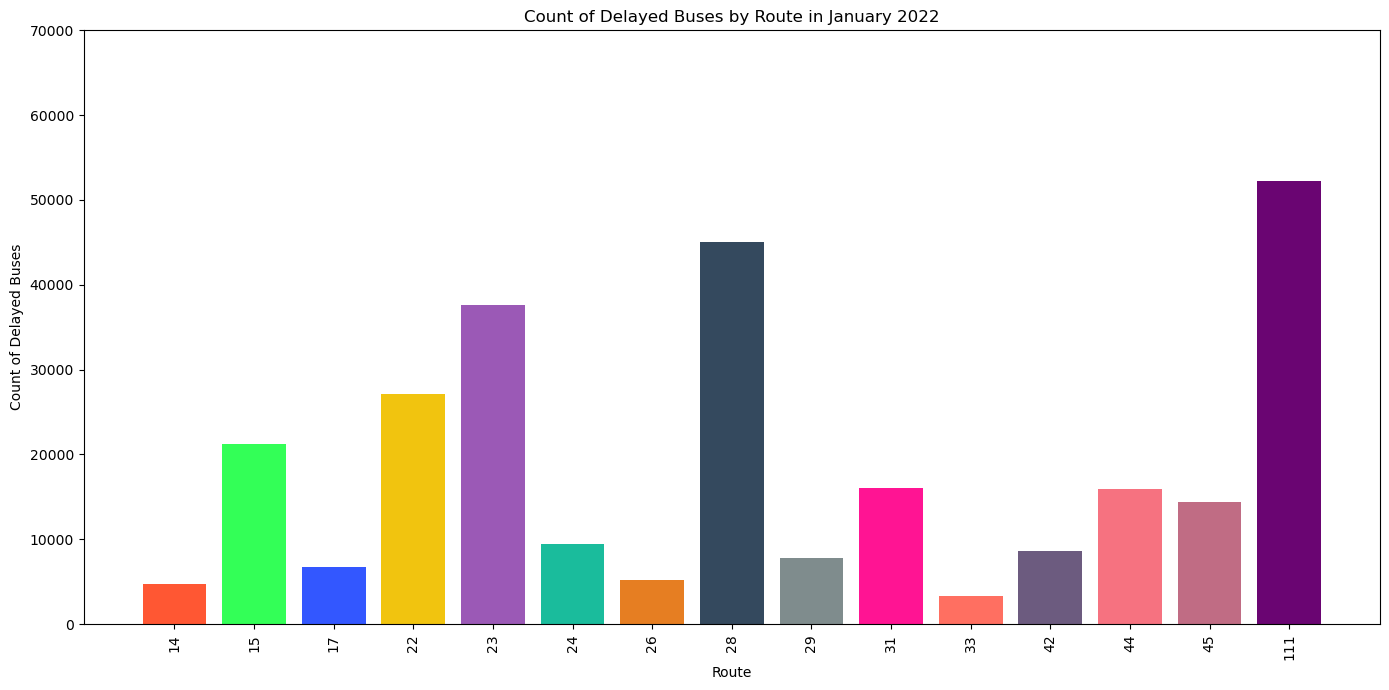

In [21]:
# Question 6: Count of delayed buses by route, separated by year

# Count of delayed buses by route for 2019
plt.figure(figsize=(14, 7))
delayed_buses_count_2019 = df[(df['year'] == 2019) & (~df['on_time'])].groupby(['route_id']).size().reset_index(name='delayed_count')
plt.bar(delayed_buses_count_2019['route_id'].astype(str), 
        delayed_buses_count_2019['delayed_count'], 
        color=colors[:len(delayed_buses_count_2019)])  # Adjust colors based on number of routes
plt.xlabel('Route')
plt.ylabel('Count of Delayed Buses')
plt.title('Count of Delayed Buses by Route in January 2019')
plt.xticks(rotation=90)
plt.ylim(0,70000)
plt.tight_layout()
plt.show()

# Count of delayed buses by route for 2022
plt.figure(figsize=(14, 7))
delayed_buses_count_2022 = df[(df['year'] == 2022) & (~df['on_time'])].groupby(['route_id']).size().reset_index(name='delayed_count')
plt.bar(delayed_buses_count_2022['route_id'].astype(str), 
        delayed_buses_count_2022['delayed_count'], 
        color=colors[:len(delayed_buses_count_2022)])  # Adjust colors based on number of routes
plt.xlabel('Route')
plt.ylabel('Count of Delayed Buses')
plt.title('Count of Delayed Buses by Route in January 2022')
plt.xticks(rotation=90)
plt.ylim(0,70000)
plt.tight_layout()
plt.show()


# Extend Question 6: Percentage

In [22]:
# Count delayed buses for 2019
delayed_buses_count_2019 = df[(df['year'] == 2019) & (~df['on_time'])].groupby(['route_id']).size().reset_index(name='delayed_count')

# Count total buses for 2019
total_buses_count_2019 = df[df['year'] == 2019].groupby(['route_id']).size().reset_index(name='total_count')

# Count delayed buses for 2022
delayed_buses_count_2022 = df[(df['year'] == 2022) & (~df['on_time'])].groupby(['route_id']).size().reset_index(name='delayed_count')

# Count total buses for 2022
total_buses_count_2022 = df[df['year'] == 2022].groupby(['route_id']).size().reset_index(name='total_count')

# Merge counts for 2019 and calculate delay percentage
merged_counts_2019 = delayed_buses_count_2019.merge(total_buses_count_2019, on='route_id')
merged_counts_2019['delay_percentage'] = (merged_counts_2019['delayed_count'] / merged_counts_2019['total_count']) * 100

# Merge counts for 2022 and calculate delay percentage
merged_counts_2022 = delayed_buses_count_2022.merge(total_buses_count_2022, on='route_id')
merged_counts_2022['delay_percentage'] = (merged_counts_2022['delayed_count'] / merged_counts_2022['total_count']) * 100


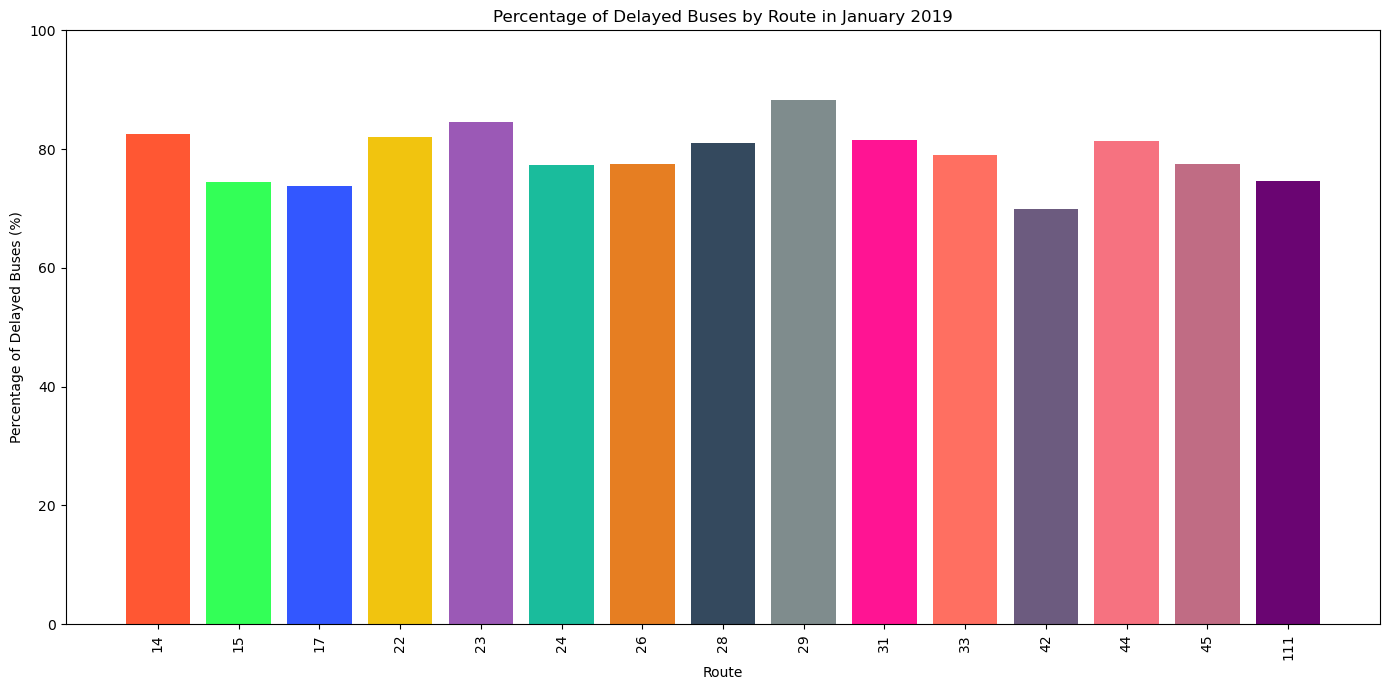

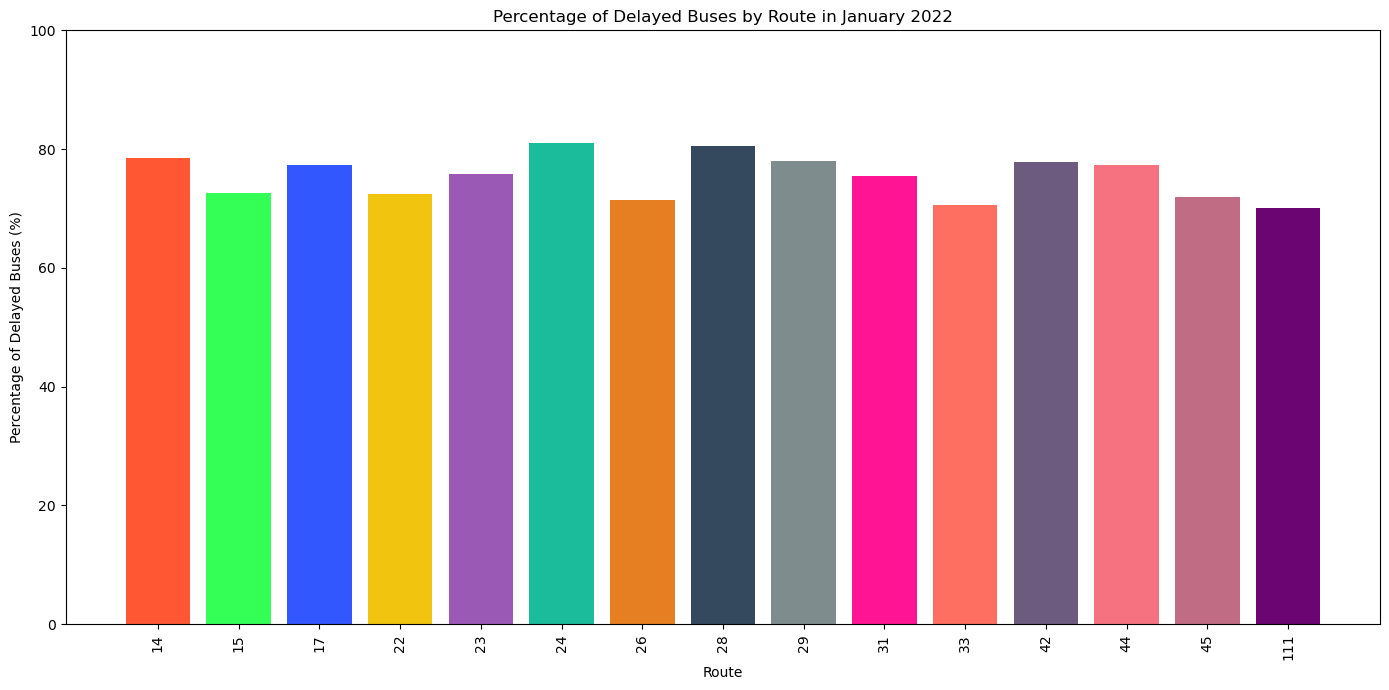

In [23]:
# Plot percentage of delayed buses for 2019
plt.figure(figsize=(14, 7))
plt.bar(merged_counts_2019['route_id'].astype(str), 
        merged_counts_2019['delay_percentage'], 
        color=colors[:len(merged_counts_2019)])  # Adjust colors based on number of routes
plt.xlabel('Route')
plt.ylabel('Percentage of Delayed Buses (%)')
plt.title('Percentage of Delayed Buses by Route in January 2019')
plt.xticks(rotation=90)
plt.ylim(0,100)
plt.tight_layout()
plt.show()

# Plot percentage of delayed buses for 2022
plt.figure(figsize=(14, 7))
plt.bar(merged_counts_2022['route_id'].astype(str), 
        merged_counts_2022['delay_percentage'], 
        color=colors[:len(merged_counts_2022)])  # Adjust colors based on number of routes
plt.xlabel('Route')
plt.ylabel('Percentage of Delayed Buses (%)')
plt.title('Percentage of Delayed Buses by Route in January 2022')
plt.xticks(rotation=90)
plt.ylim(0,100)
plt.tight_layout()
plt.show()


# What can be optimized?
    1. Use + - to calculate early and delayed, it could be better reflects the reality
    2. wait time is not really reflecting the reality, since no matter what buffer time it sets, some marginal cases
        will be counted into calculation and generates misleading stats.